# Midterm Project 1 – Model 2: Complex CNN (ResNet nhỏ tự thiết kế)

**Nhóm G8 – AI66A – DNN**

Notebook thực hiện yêu cầu **Model 2**: tự thiết kế một CNN phức tạp hơn Model 1 bằng các **CNN block** (conv, pooling, fully connected), kèm tiền xử lý và đánh giá bằng các metric phù hợp.

**Mục lục**
0. Kiểm tra GPU
1. Cấu hình & thư viện
2. Khám phá và làm sạch dữ liệu
3. Tiền xử lý: normalize + augmentation
4. Xây dựng Model 2 (ResNet nhỏ)
5. Huấn luyện
6. Đánh giá trên tập test
7. Lưu kết quả & so sánh với Model 1

## 0. Kiểm tra và thiết lập GPU

In [1]:
import gc
import time
import torch

print("PyTorch:", torch.__version__)
if not torch.cuda.is_available():
    if torch.version.cuda is None:
        raise RuntimeError("Notebook này yêu cầu GPU NVIDIA CUDA, nhưng PyTorch hiện tại là bản CPU-only. Cài PyTorch có CUDA và bật GPU trước khi chạy.")
    raise RuntimeError("Notebook này chỉ chạy bằng GPU NVIDIA CUDA. Không tìm thấy CUDA; kiểm tra driver NVIDIA và cấu hình GPU của môi trường.")

DEVICE = torch.device("cuda:0")
torch.cuda.set_device(DEVICE)
torch.backends.cudnn.benchmark = True

# Thu gom bộ nhớ không còn được tham chiếu và cache rảnh của tiến trình hiện tại.
gc.collect()
torch.cuda.empty_cache()
torch.cuda.ipc_collect()

props = torch.cuda.get_device_properties(DEVICE)
free_bytes, total_bytes = torch.cuda.mem_get_info(DEVICE)
print(f"GPU CUDA: {props.name} | VRAM {total_bytes / 1024**3:.1f} GB | "
      f"đang trống {free_bytes / 1024**3:.2f} GB | CUDA {torch.version.cuda} | "
      f"cuDNN {torch.backends.cudnn.version()} | số GPU: {torch.cuda.device_count()}")

# Smoke test nhỏ để xác nhận phép tính thật sự chạy trên CUDA.
a = b = None
t0 = time.time()
try:
    a = torch.randn(1024, 1024, device=DEVICE)
    b = a @ a
    torch.cuda.synchronize(DEVICE)
    print(f"Thiết bị đang dùng: {DEVICE} | CUDA matmul 1024x1024 mất {time.time() - t0:.3f}s")
except RuntimeError as exc:
    gc.collect()
    torch.cuda.empty_cache()
    free_bytes, _ = torch.cuda.mem_get_info(DEVICE)
    raise RuntimeError(
        f"Không chạy được phép thử trên GPU (còn trống {free_bytes / 1024**3:.2f} GB). "
        "Hãy dừng kernel/notebook khác đang dùng GPU hoặc giảm BATCH_SIZE. "
        "Notebook chỉ giải phóng cache rảnh của tiến trình hiện tại, không thể giải phóng bộ nhớ của tiến trình khác."
    ) from exc
finally:
    del a, b
    gc.collect()
    torch.cuda.empty_cache()

PyTorch: 2.5.1+cu121
GPU CUDA: NVIDIA GeForce RTX 4070 Ti SUPER | VRAM 15.5 GB | đang trống 8.74 GB | CUDA 12.1 | cuDNN 92600 | số GPU: 1
Thiết bị đang dùng: cuda:0 | CUDA matmul 1024x1024 mất 0.064s


## 1. Cấu hình & thư viện

In [2]:
import os, json, random, hashlib, copy
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

In [5]:
# ============ CẤU HÌNH (chỉnh ở đây) ============
SEED          = 42
IMG_SIZE      = 128       # nên giữ giống Model 1 để so sánh công bằng
BATCH_SIZE    = 64
EPOCHS        = 40
MAX_LR        = 2e-3      # đỉnh learning rate của OneCycle
WEIGHT_DECAY  = 5e-4
LABEL_SMOOTH  = 0.1
DROPOUT       = 0.3
NUM_WORKERS   = 2
USE_CLASS_WEIGHTS = True

# Kiến trúc
BASE_CH  = 32             # độ rộng: 32 -> (32,64,128,256) ~2.8M tham số | 64 -> (64,...,512) ~11M tham số
USE_BN   = True           # đặt False để làm ablation "không BatchNorm"
USE_SKIP = True           # đặt False để làm ablation "không skip connection"

USE_AMP = DEVICE.type == "cuda"   # mixed precision: nhanh hơn và tiết kiệm VRAM trên GPU NVIDIA

RUN_NAME = "model2_resnet" + ("" if USE_BN else "_noBN") + ("" if USE_SKIP else "_noSkip")

# CANDIDATES = [Path("data/cut"), Path("../data/cut"), Path("data/raw"), Path("../data/raw")]
# DATA_DIR = next((p for p in CANDIDATES if (p / "train").is_dir()), None)
# assert DATA_DIR is not None, "Không tìm thấy thư mục dữ liệu. Hãy gán DATA_DIR thủ công."
# OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)

# random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
# rng = random.Random(SEED)
# print("Dữ liệu:", DATA_DIR.resolve(), "| Run:", RUN_NAME, "| AMP:", USE_AMP)



random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
rng = random.Random(SEED)


# Tìm data/cut trước, rồi data/raw, từ thư mục hiện tại và thư mục cha.
# Hỗ trợ cả trường hợp workspace mở ở thư mục cha của project.
WORKSPACE_ROOT = Path.cwd().resolve()
SEARCH_ROOTS = [WORKSPACE_ROOT, *WORKSPACE_ROOT.parents]
PROJECT_ROOTS = SEARCH_ROOTS + [
    child for child in WORKSPACE_ROOT.iterdir()
    if child.is_dir() and (child / "data").is_dir()
]
# CANDIDATES = [root / "data" / split for split in ("cut", "raw") for root in PROJECT_ROOTS]
CANDIDATES = [root / "data" / "raw" for root in PROJECT_ROOTS]
DATA_DIR = next((p for p in CANDIDATES if (p / "train").is_dir()), None)
assert DATA_DIR is not None, (
    f"Không tìm thấy data/cut hoặc data/raw từ thư mục {WORKSPACE_ROOT}. "
    "Hãy gán DATA_DIR thủ công, ví dụ: DATA_DIR = Path('/content/data/cut')."
)

OUT_DIR = Path("outputs"); OUT_DIR.mkdir(exist_ok=True)
print("Dữ liệu:", DATA_DIR.resolve(), "| Run:", RUN_NAME, "| AMP:", USE_AMP)

Dữ liệu: /home/pc/AAA/project/deepnn/G8_AI66A_DNN/data/raw | Run: model2_resnet | AMP: True


## 2. Khám phá và làm sạch dữ liệu

Giống Model 1 để hai mô hình được huấn luyện trên **cùng một tập dữ liệu đã làm sạch**: loại file ảnh hỏng, loại ảnh trùng lặp trong và giữa các tập (ưu tiên giữ `test` > `val` > `train` để tránh rò rỉ dữ liệu).

In [6]:
IMAGE_EXTS = {".bmp", ".jpeg", ".jpg", ".png", ".ppm", ".pgm", ".tif", ".tiff", ".webp"}
SPLITS = ["train", "val", "test"]

CLASS_NAMES = sorted(p.name for p in (DATA_DIR / "train").iterdir() if p.is_dir())
CLASS_TO_IDX = {c: i for i, c in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)
print(f"Số lớp: {NUM_CLASSES} -> {CLASS_NAMES}")

raw_samples = {
    s: [(p, CLASS_TO_IDX[c]) for c in CLASS_NAMES
        for p in sorted((DATA_DIR / s / c).rglob("*")) if p.is_file() and p.suffix.lower() in IMAGE_EXTS]
    for s in SPLITS
}
summary = pd.DataFrame({s: Counter(CLASS_NAMES[y] for _, y in raw_samples[s]) for s in SPLITS}).fillna(0).astype(int)
summary["total"] = summary.sum(axis=1)
summary.loc["TỔNG"] = summary.sum()
summary

Số lớp: 4 -> ['CNV', 'DME', 'DRUSEN', 'NORMAL']


,train,val,test,total
CNV,26218,7491,3746,37455
DME,8118,2319,1161,11598
DRUSEN,6206,1773,887,8866
NORMAL,35973,10278,5139,51390
TỔNG,76515,21861,10933,109309


In [ ]:
# 2) Loại ảnh trùng (ưu tiên giữ: test > val > train)
seen_hash, clean, dup_count = {}, {s: [] for s in SPLITS}, Counter()
for s in ["test", "val", "train"]:
    for p, y in valid[s]:
        h = hashlib.md5(p.read_bytes()).hexdigest()
        if h in seen_hash:
            dup_count[(s, seen_hash[h])] += 1
            continue
        seen_hash[h] = s
        clean[s].append((p, y))
print("Ảnh trùng bị loại:", sum(dup_count.values()))
for (drop_in, kept_in), n in dup_count.items():
    print(f"  - {n} ảnh ở '{drop_in}' trùng với ảnh ở '{kept_in}'")

clean_summary = pd.DataFrame({s: Counter(CLASS_NAMES[y] for _, y in clean[s]) for s in SPLITS}).fillna(0).astype(int)
clean_summary["total"] = clean_summary.sum(axis=1)
clean_summary.loc["TỔNG"] = clean_summary.sum()
print("\nSau khi làm sạch:")
clean_summary

File ảnh hỏng: 0
Ảnh trùng bị loại: 7866
  - 85 ảnh ở 'test' trùng với ảnh ở 'test'
  - 345 ảnh ở 'val' trùng với ảnh ở 'test'
  - 301 ảnh ở 'val' trùng với ảnh ở 'val'
  - 2301 ảnh ở 'train' trùng với ảnh ở 'val'
  - 3622 ảnh ở 'train' trùng với ảnh ở 'train'
  - 1212 ảnh ở 'train' trùng với ảnh ở 'test'

Sau khi làm sạch:


,train,val,test,total
CNV,21118,7031,3683,31832
DME,7736,2279,1156,11171
DRUSEN,5528,1715,874,8117
NORMAL,34998,10190,5135,50323
TỔNG,69380,21215,10848,101443


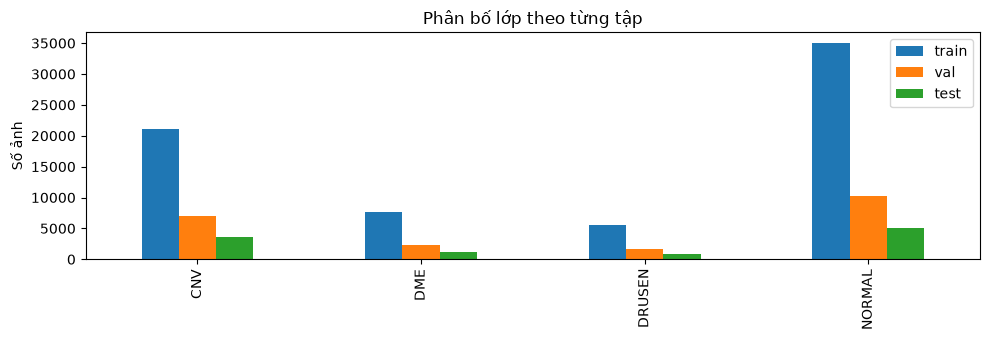

Tỉ lệ mất cân bằng (max/min) ở train: 6.33


In [8]:
# Phân bố lớp ở train + mức độ mất cân bằng
train_counts = np.array([sum(1 for _, y in clean["train"] if y == i) for i in range(NUM_CLASSES)])
imb_ratio = train_counts.max() / max(train_counts.min(), 1)
clean_summary.drop(index="TỔNG")[SPLITS].plot(kind="bar", figsize=(10, 3.5), title="Phân bố lớp theo từng tập")
plt.ylabel("Số ảnh"); plt.tight_layout(); plt.show()
print("Tỉ lệ mất cân bằng (max/min) ở train:", round(imb_ratio, 2))

## 3. Tiền xử lý: Normalize + Augmentation

So với Model 1, augmentation **mạnh hơn** vì mô hình có nhiều tham số hơn và dễ overfit hơn:
`RandomResizedCrop` thay cho resize cố định, thêm `RandomErasing` (dạng Cutout) sau khi normalize.

> ⚠️ Nếu dataset nhạy cảm với phép lật (chữ số, chữ cái, ảnh y tế có hướng cố định) thì bỏ `RandomHorizontalFlip`.

In [9]:
class ImageListDataset(Dataset):
    def __init__(self, samples, transform=None):
        self.samples, self.transform = samples, transform
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, i):
        path, y = self.samples[i]
        img = Image.open(path).convert("RGB")
        return (self.transform(img) if self.transform else img), y

# mean/std chỉ tính trên tập train
stat_loader = DataLoader(
    ImageListDataset(clean["train"], transforms.Compose([transforms.Resize((IMG_SIZE, IMG_SIZE)), transforms.ToTensor()])),
    batch_size=128, num_workers=NUM_WORKERS)
n, s1, s2 = 0, torch.zeros(3), torch.zeros(3)
for x, _ in stat_loader:
    s1 += x.mean(dim=[2, 3]).sum(0); s2 += (x ** 2).mean(dim=[2, 3]).sum(0); n += x.size(0)
MEAN = s1 / n
STD = (s2 / n - MEAN ** 2).sqrt()
print("Mean:", MEAN.tolist(), "\nStd :", STD.tolist())

Mean: [0.19020166993141174, 0.19020166993141174, 0.19020166993141174] 
Std : [0.21419018507003784, 0.21419018507003784, 0.21419018507003784]


train=69380  val=21215  test=10848


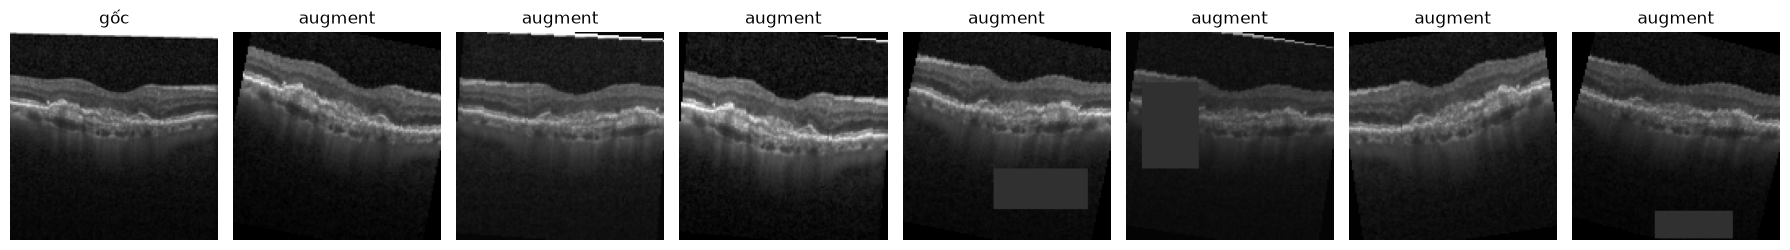

In [10]:
train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
    transforms.RandomHorizontalFlip(0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.15)),
])
eval_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN.tolist(), STD.tolist()),
])

train_ds = ImageListDataset(clean["train"], train_tf)
val_ds   = ImageListDataset(clean["val"],   eval_tf)
test_ds  = ImageListDataset(clean["test"],  eval_tf)

g = torch.Generator()
g.manual_seed(SEED)
kw = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=DEVICE.type == "cuda",
          persistent_workers=NUM_WORKERS > 0)
train_loader = DataLoader(train_ds, shuffle=True,  generator=g, **kw)
val_loader   = DataLoader(val_ds,   shuffle=False, **kw)
test_loader  = DataLoader(test_ds,  shuffle=False, **kw)
print(f"train={len(train_ds)}  val={len(val_ds)}  test={len(test_ds)}")

# Minh họa augmentation
orig = Image.open(clean["train"][0][0]).convert("RGB")
fig, axes = plt.subplots(1, 8, figsize=(18, 2.6))
axes[0].imshow(orig.resize((IMG_SIZE, IMG_SIZE))); axes[0].set_title("gốc"); axes[0].axis("off")
for k in range(1, 8):
    t = train_tf(orig)
    axes[k].imshow((t * STD.view(3, 1, 1) + MEAN.view(3, 1, 1)).clamp(0, 1).permute(1, 2, 0).numpy())
    axes[k].set_title("augment"); axes[k].axis("off")
plt.tight_layout(); plt.show()

## 4. Model 2 – ResNet nhỏ tự thiết kế

| Thành phần | Chi tiết |
|---|---|
| Stem | Conv 3×3 (`BASE_CH`) → BN → ReLU |
| Stage 1 | 2 × ResBlock (`BASE_CH`), stride 1 |
| Stage 2 | 2 × ResBlock (`2·BASE_CH`), block đầu stride 2 |
| Stage 3 | 2 × ResBlock (`4·BASE_CH`), block đầu stride 2 |
| Stage 4 | 2 × ResBlock (`8·BASE_CH`), block đầu stride 2 |
| Head | Global Average Pooling → Dropout → Linear (số lớp) |

**ResBlock**: Conv3×3 → BN → ReLU → Conv3×3 → BN, cộng với đường tắt (skip), rồi ReLU. Khi đổi số kênh hoặc stride thì đường tắt dùng Conv 1×1 + BN.

Việc giảm kích thước dùng **stride 2** thay cho MaxPool; phần cuối dùng **GAP** thay cho Flatten + FC lớn của Model 1 để giảm mạnh số tham số. Hai cờ `USE_BN` và `USE_SKIP` cho phép làm ablation nhanh.

In [11]:
class ResBlock(nn.Module):
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        norm = nn.BatchNorm2d if USE_BN else (lambda c: nn.Identity())
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=not USE_BN)
        self.bn1 = norm(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, 1, 1, bias=not USE_BN)
        self.bn2 = norm(out_ch)
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(nn.Conv2d(in_ch, out_ch, 1, stride, bias=not USE_BN), norm(out_ch))
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        if USE_SKIP:
            out = out + self.shortcut(x)
        return F.relu(out, inplace=True)


class ResNetSmall(nn.Module):
    def __init__(self, num_classes, base=32, dropout=0.3):
        super().__init__()
        norm = nn.BatchNorm2d if USE_BN else (lambda c: nn.Identity())
        layers = [nn.Conv2d(3, base, 3, 1, 1, bias=not USE_BN), norm(base), nn.ReLU(inplace=True)]
        in_ch = base
        for i, mult in enumerate([1, 2, 4, 8]):
            out_ch = base * mult
            layers += [ResBlock(in_ch, out_ch, stride=1 if i == 0 else 2), ResBlock(out_ch, out_ch, 1)]
            in_ch = out_ch
        self.features = nn.Sequential(*layers)
        self.head = nn.Sequential(nn.AdaptiveAvgPool2d(1), nn.Flatten(), nn.Dropout(dropout), nn.Linear(in_ch, num_classes))
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode="fan_out", nonlinearity="relu")

    def forward(self, x):
        return self.head(self.features(x))


model = ResNetSmall(NUM_CLASSES, BASE_CH, DROPOUT).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
n_conv = sum(isinstance(m, nn.Conv2d) for m in model.modules())
print(f"Số lớp Conv: {n_conv} | Tổng số tham số: {n_params:,}")
print("Kiểm tra output:", tuple(model(torch.zeros(2, 3, IMG_SIZE, IMG_SIZE, device=DEVICE)).shape))

Số lớp Conv: 20 | Tổng số tham số: 2,796,068
Kiểm tra output: (2, 4)


## 5. Huấn luyện

- **AdamW** + **OneCycleLR** (warm-up rồi giảm dần theo cosine, cập nhật sau mỗi batch).
- **Label smoothing** để giảm quá tự tin, **weight decay** để regularize.
- **Mixed precision (AMP)** khi chạy GPU NVIDIA.
- Lưu checkpoint tốt nhất theo `val_loss` (loss không smoothing). Không dùng early stopping vì OneCycle cần chạy hết chu kỳ.

In [12]:
if USE_CLASS_WEIGHTS and imb_ratio > 1.5:
    w = train_counts.sum() / (NUM_CLASSES * np.maximum(train_counts, 1))
    class_weights = torch.tensor(w, dtype=torch.float32, device=DEVICE)
    print("Dùng class weights:", np.round(w, 3))
else:
    class_weights = None
    print("Dữ liệu tương đối cân bằng -> không dùng class weights")

criterion     = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=LABEL_SMOOTH)  # để huấn luyện
val_criterion = nn.CrossEntropyLoss(weight=class_weights)                                # để chọn model tốt nhất
optimizer = torch.optim.AdamW(model.parameters(), lr=MAX_LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=MAX_LR, epochs=EPOCHS,
                                                steps_per_epoch=len(train_loader), pct_start=0.2)
scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "lr": []}
best_val, best_state = float("inf"), None
CKPT = OUT_DIR / f"{RUN_NAME}.pt"

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    # ---- train
    model.train()
    tl, tc, tn = 0.0, 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            out = model(x)
            loss = criterion(out, y)
        scaler.scale(loss).backward()
        scaler.step(optimizer); scaler.update(); scheduler.step()
        tl += loss.item() * x.size(0); tc += (out.argmax(1) == y).sum().item(); tn += x.size(0)

    # ---- validation
    model.eval()
    vl, vc, vn = 0.0, 0, 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
                out = model(x)
            vl += val_criterion(out.float(), y).item() * x.size(0)
            vc += (out.argmax(1) == y).sum().item(); vn += x.size(0)

    row = [tl / tn, vl / vn, tc / tn, vc / vn, optimizer.param_groups[0]["lr"]]
    for k, v in zip(history, row): history[k].append(v)

    flag = ""
    if row[1] < best_val:
        best_val, best_state, flag = row[1], copy.deepcopy(model.state_dict()), "  <-- best"
        torch.save({"model": best_state, "classes": CLASS_NAMES, "img_size": IMG_SIZE, "base_ch": BASE_CH,
                    "mean": MEAN.tolist(), "std": STD.tolist()}, CKPT)
    print(f"Epoch {epoch:02d}/{EPOCHS} | train loss {row[0]:.4f} acc {row[2]:.4f} | "
          f"val loss {row[1]:.4f} acc {row[3]:.4f} | lr {row[4]:.1e}{flag}")

train_time = time.time() - t0
print(f"\nThời gian huấn luyện: {train_time / 60:.1f} phút | best val_loss = {best_val:.4f}")
model.load_state_dict(best_state)

Dùng class weights: [0.821 2.242 3.138 0.496]
Epoch 01/40 | train loss 0.9883 acc 0.7316 | val loss 0.5694 acc 0.8303 | lr 1.5e-04  <-- best
Epoch 02/40 | train loss 0.7860 acc 0.8668 | val loss 0.4783 acc 0.9247 | lr 3.6e-04  <-- best
Epoch 03/40 | train loss 0.7440 acc 0.8923 | val loss 0.3531 acc 0.9286 | lr 6.7e-04  <-- best
Epoch 04/40 | train loss 0.7274 acc 0.9032 | val loss 0.4398 acc 0.9129 | lr 1.0e-03
Epoch 05/40 | train loss 0.7115 acc 0.9093 | val loss 0.6317 acc 0.8311 | lr 1.4e-03
Epoch 06/40 | train loss 0.7030 acc 0.9143 | val loss 0.3226 acc 0.9364 | lr 1.7e-03  <-- best
Epoch 07/40 | train loss 0.6918 acc 0.9206 | val loss 0.4199 acc 0.9320 | lr 1.9e-03
Epoch 08/40 | train loss 0.6832 acc 0.9248 | val loss 0.3580 acc 0.9409 | lr 2.0e-03
Epoch 09/40 | train loss 0.6697 acc 0.9311 | val loss 0.3488 acc 0.9568 | lr 2.0e-03
Epoch 10/40 | train loss 0.6619 acc 0.9339 | val loss 0.3228 acc 0.9572 | lr 2.0e-03
Epoch 11/40 | train loss 0.6535 acc 0.9387 | val loss 0.3368 acc

<All keys matched successfully>

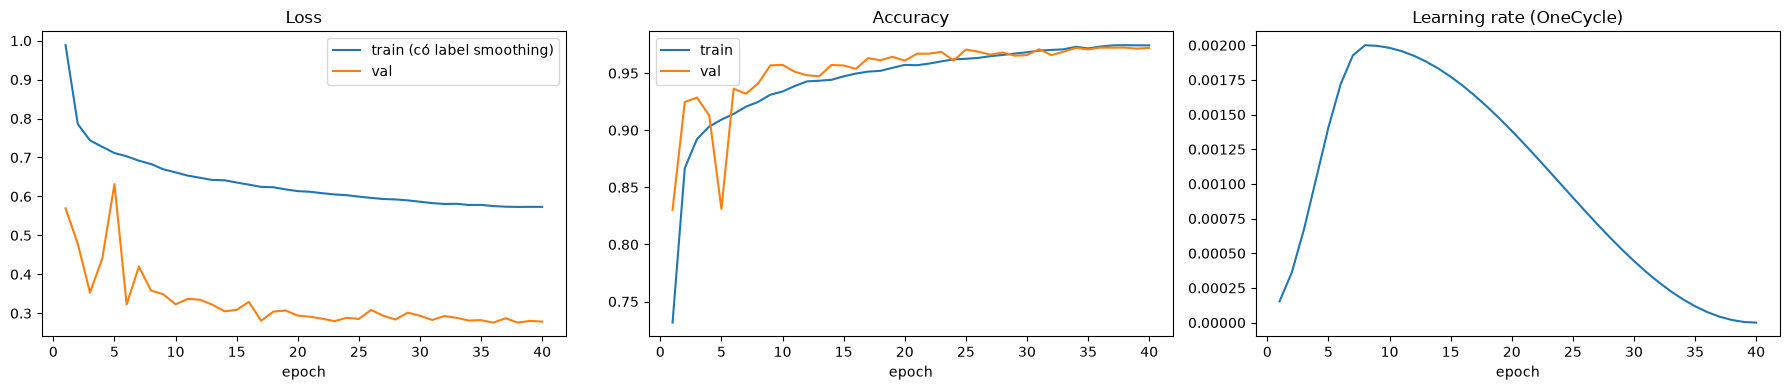

In [13]:
ep = range(1, len(history["train_loss"]) + 1)
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
ax[0].plot(ep, history["train_loss"], label="train (có label smoothing)"); ax[0].plot(ep, history["val_loss"], label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].legend()
ax[1].plot(ep, history["train_acc"], label="train"); ax[1].plot(ep, history["val_acc"], label="val")
ax[1].set_title("Accuracy"); ax[1].set_xlabel("epoch"); ax[1].legend()
ax[2].plot(ep, history["lr"]); ax[2].set_title("Learning rate (OneCycle)"); ax[2].set_xlabel("epoch")
plt.tight_layout()
plt.show()

## 6. Đánh giá trên tập test

Dùng cùng metric với Model 1: **Accuracy**, **Precision / Recall / F1** theo lớp, **macro-F1** và **weighted-F1**, cùng **confusion matrix**.

In [14]:
model.eval()
ys, ps, probs = [], [], []
with torch.no_grad():
    for x, y in test_loader:
        with torch.autocast(device_type=DEVICE.type, enabled=USE_AMP):
            out = model(x.to(DEVICE, non_blocking=True))
        probs.append(F.softmax(out.float(), 1).cpu().numpy())
        ps.append(out.argmax(1).cpu().numpy()); ys.append(y.numpy())
y_true, y_pred, y_prob = np.concatenate(ys), np.concatenate(ps), np.concatenate(probs)

acc = accuracy_score(y_true, y_pred)
p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
_, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)

print(f"Test accuracy : {acc:.4f}")
print(f"Macro precision/recall/F1: {p_macro:.4f} / {r_macro:.4f} / {f1_macro:.4f}")
print(f"Weighted F1   : {f1_weighted:.4f}\n")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4, zero_division=0))

Test accuracy : 0.9716
Macro precision/recall/F1: 0.9391 / 0.9674 / 0.9522
Weighted F1   : 0.9721

              precision    recall  f1-score   support

         CNV     0.9902    0.9631    0.9765      3683
         DME     0.9319    0.9706    0.9508      1156
      DRUSEN     0.8409    0.9554    0.8945       874
      NORMAL     0.9935    0.9807    0.9871      5135

    accuracy                         0.9716     10848
   macro avg     0.9391    0.9674    0.9522     10848
weighted avg     0.9735    0.9716    0.9721     10848



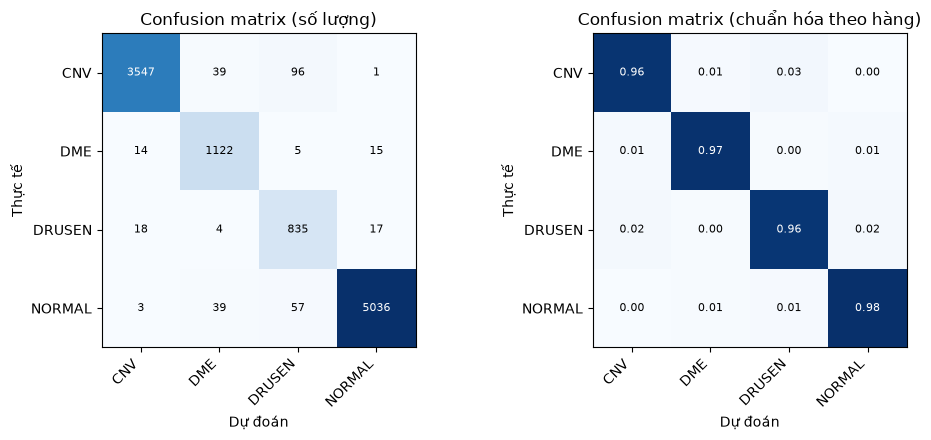

In [15]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm / cm.sum(axis=1, keepdims=True).clip(min=1)

fig, ax = plt.subplots(1, 2, figsize=(max(10, NUM_CLASSES * 1.6), max(4.5, NUM_CLASSES * 0.7)))
for a, M, title, fmt in [(ax[0], cm, "Confusion matrix (số lượng)", "d"),
                         (ax[1], cm_norm, "Confusion matrix (chuẩn hóa theo hàng)", ".2f")]:
    a.imshow(M, cmap="Blues")
    a.set_xticks(range(NUM_CLASSES)); a.set_yticks(range(NUM_CLASSES))
    a.set_xticklabels(CLASS_NAMES, rotation=45, ha="right"); a.set_yticklabels(CLASS_NAMES)
    a.set_xlabel("Dự đoán"); a.set_ylabel("Thực tế"); a.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            a.text(j, i, format(M[i, j], fmt), ha="center", va="center",
                   color="white" if M[i, j] > M.max() / 2 else "black", fontsize=8)
plt.tight_layout()
plt.show()

Số ảnh dự đoán sai: 308/10848


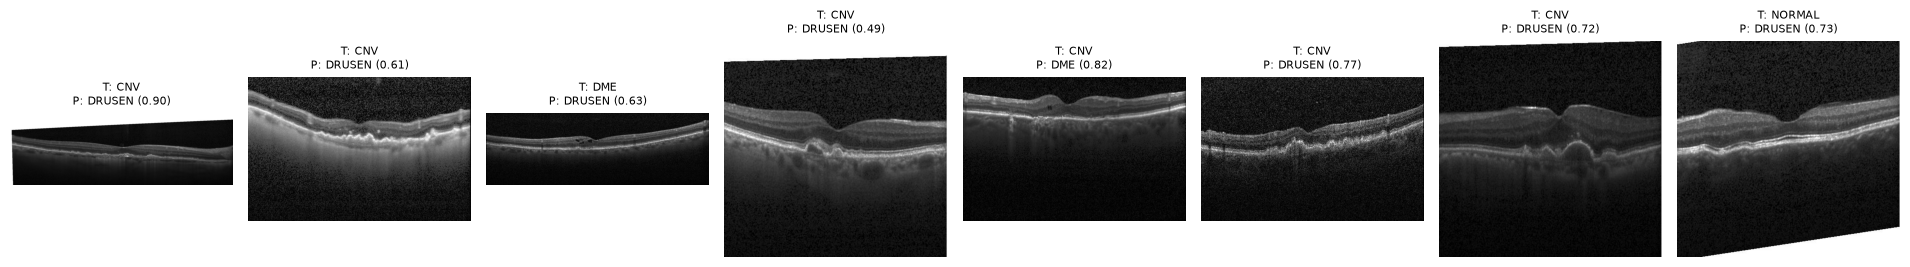

In [16]:
# Một số ảnh bị dự đoán sai (kèm độ tin cậy)
wrong = np.where(y_true != y_pred)[0]
print(f"Số ảnh dự đoán sai: {len(wrong)}/{len(y_true)}")
if len(wrong):
    pick = rng.sample(list(wrong), min(8, len(wrong)))
    fig, axes = plt.subplots(1, len(pick), figsize=(2.4 * len(pick), 3), squeeze=False)
    for a, idx in zip(axes[0], pick):
        a.imshow(Image.open(clean["test"][idx][0]).convert("RGB")); a.axis("off")
        a.set_title(f"T: {CLASS_NAMES[y_true[idx]]}\nP: {CLASS_NAMES[y_pred[idx]]} ({y_prob[idx].max():.2f})", fontsize=8)
    plt.tight_layout(); plt.show()

## 7. Lưu kết quả & so sánh với Model 1

In [ ]:
results = {
    "model": f"Model 2 - {RUN_NAME}",
    "params": int(n_params),
    "img_size": IMG_SIZE,
    "epochs_run": len(history["train_loss"]),
    "train_time_min": round(train_time / 60, 2),
    "best_val_loss": float(best_val),
    "test_accuracy": float(acc),
    "test_macro_precision": float(p_macro),
    "test_macro_recall": float(r_macro),
    "test_macro_f1": float(f1_macro),
    "test_weighted_f1": float(f1_weighted),
    "classes": CLASS_NAMES,
}
with open(OUT_DIR / f"{RUN_NAME}_metrics.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
pd.DataFrame(history).to_csv(OUT_DIR / f"{RUN_NAME}_history.csv", index=False)

# Bảng so sánh với Model 1 (nếu đã chạy notebook Model 1 và có file metrics)
table = {RUN_NAME: results}
m1_path = OUT_DIR / "model1_metrics.json"
if m1_path.exists():
    table = {"Model 1 (Simple CNN)": json.loads(m1_path.read_text(encoding="utf-8")), RUN_NAME: results}
else:
    print("Chưa thấy outputs/model1_metrics.json -> chạy notebook Model 1 trước để có bảng so sánh.")
keys = ["params", "train_time_min", "best_val_loss", "test_accuracy", "test_macro_f1", "test_weighted_f1"]
pd.DataFrame(table).loc[keys]

### Nhận xét (điền sau khi chạy)

- **So với Model 1**: Accuracy và macro-F1 tăng bao nhiêu? Số tham số và thời gian huấn luyện thay đổi thế nào?
- **Overfitting?** Khoảng cách giữa đường cong train và val so với Model 1.
- **Lớp bị nhầm nhiều** trong confusion matrix và vì sao (nhìn các ảnh dự đoán sai).
- **Ablation (tùy chọn)**: đổi `USE_BN = False` hoặc `USE_SKIP = False` ở ô cấu hình rồi chạy lại. Kết quả được lưu với hậu tố `_noBN` / `_noSkip` nên không ghi đè lẫn nhau, dùng để so sánh đóng góp của từng thành phần.
- **Hướng tiếp theo**: Model 3 (Transfer Learning / Fine-tuning) với trọng số pretrained.